GitHub Link: https://github.com/inezakevin23/formative2-pca-pair-team-2.git

Dataset Link: https://www.kaggle.com/datasets/abbas829/africa-malaria-dataset


# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





## Step 1: Data preparation
###Load the file and detect non-numeric columns

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "DatasetAfricaMalaria.csv"   # upload this file next to the notebook
print("Libraries loaded. numpy", np.__version__, "| data file:", DATA_PATH)

Libraries loaded. numpy 2.1.3 | data file: DatasetAfricaMalaria.csv


In [2]:
import os
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Upload {DATA_PATH} to this folder first (Colab: left sidebar > folder icon > upload).")
with open(DATA_PATH, newline="", encoding="utf-8") as f:
    reader = csv.reader(f)
    header = next(reader)
    raw_rows = [row for row in reader]

print("Rows:", len(raw_rows), "| Columns:", len(header))
for r in raw_rows[:3]:
    print(r[:6])

Rows: 594 | Columns: 27
['Algeria', '2007', 'DZA', '0.01', '26', '']
['Angola', '2007', 'AGO', '286.72', '1533485', '18']
['Benin', '2007', 'BEN', '480.24', '0', '']


In [3]:
def is_number(s):
    try:
        float(s)
        return True
    except ValueError:
        return False

numeric_cols, text_cols = [], []
for j, name in enumerate(header):
    values = [r[j].strip() for r in raw_rows if r[j].strip() != ""]
    if all(is_number(v) for v in values):
        numeric_cols.append(j)
    else:
        text_cols.append(j)

print("NON-NUMERIC columns:", [header[j] for j in text_cols])
print("NUMERIC columns    :", len(numeric_cols))

NON-NUMERIC columns: ['Country Name', 'Country Code', 'geometry']
NUMERIC columns    : 24


### 0.2 Convert to a numeric matrix and inspect missing values

In [4]:
def to_float(s):
    s = s.strip()
    return float(s) if s != "" else np.nan

X_all = np.array([[to_float(r[j]) for j in numeric_cols] for r in raw_rows])
num_names = [header[j] for j in numeric_cols]
print("Shape of numeric matrix:", X_all.shape)

Shape of numeric matrix: (594, 24)


Column                                                                       NaN       %
Year                                                                           0     0.0
Incidence of malaria (per 1,000 population at risk)                           44     7.4
Malaria cases reported                                                        44     7.4
Use of insecticide-treated bed nets (% of under-5 population)                462    77.8
Children with fever receiving antimalarial drugs (% of children under age    472    79.5
Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pre    488    82.2
People using safely managed drinking water services (% of population)        495    83.3
People using safely managed drinking water services, rural (% of rural po    506    85.2
People using safely managed drinking water services, urban (% of urban po    418    70.4
People using safely managed sanitation services (% of population)            462    77.8
People using safely m

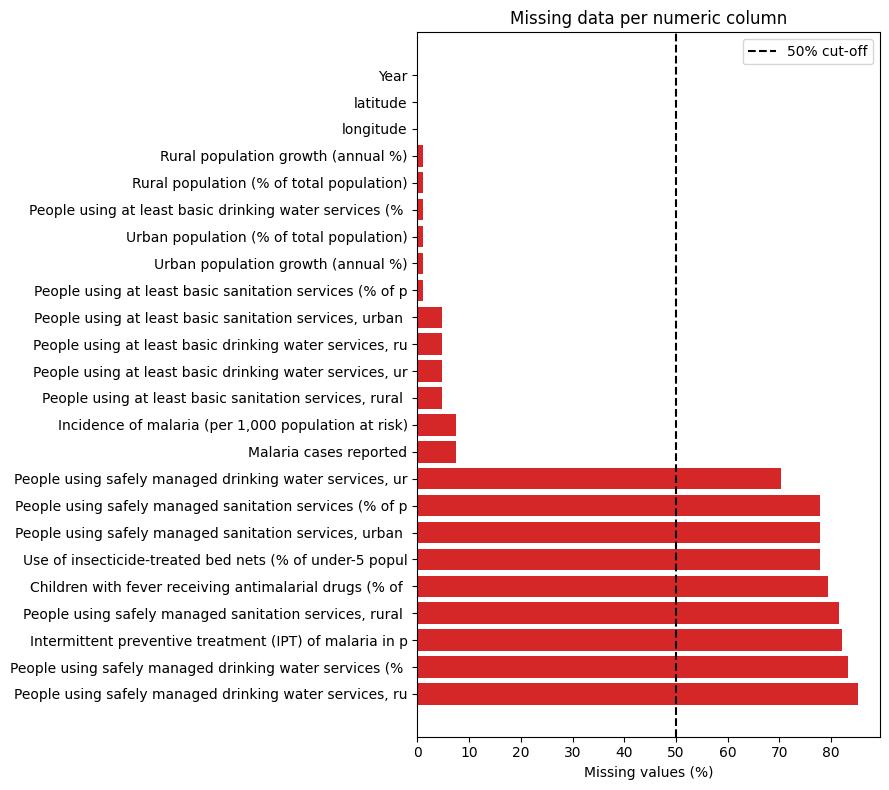

In [5]:
nan_count = np.isnan(X_all).sum(axis=0)
nan_pct = 100 * nan_count / X_all.shape[0]

print(f"{'Column':<75}{'NaN':>5}{'%':>8}")
for name, c, p in zip(num_names, nan_count, nan_pct):
    print(f"{name[:73]:<75}{c:>5}{p:>8.1f}")
print("\nTotal NaN cells:", int(nan_count.sum()), "of", X_all.size)

order = np.argsort(nan_pct)[::-1]
plt.figure(figsize=(9, 8))
plt.barh([num_names[i][:55] for i in order], nan_pct[order], color="tab:red")
plt.axvline(50, color="black", linestyle="--", label="50% cut-off")
plt.xlabel("Missing values (%)")
plt.title("Missing data per numeric column")
plt.legend()
plt.tight_layout()
plt.show()

**Fake zeros.** `Malaria cases reported = 0` while incidence is above 50 per 1,000 is impossible (Benin: 480 per 1,000 but 0 cases), so these zeros are really *missing* and are set to NaN before imputation.

In [6]:
i_inc = num_names.index("Incidence of malaria (per 1,000 population at risk)")
i_cases = num_names.index("Malaria cases reported")

fake_zero = (X_all[:, i_cases] == 0) & (X_all[:, i_inc] > 50)
print("Zeros in 'cases' with incidence > 50:", int(fake_zero.sum()))
X_all[fake_zero, i_cases] = np.nan

Zeros in 'cases' with incidence > 50: 42


### 0.3 Drop unusable columns

In [7]:
nan_pct = 100 * np.isnan(X_all).sum(axis=0) / X_all.shape[0]
MAX_MISSING = 50.0     # columns with more than half of their values missing are dropped

drop_names = {"Year", "latitude", "longitude",
              "Urban population (% of total population)"}

keep_idx = [j for j, n in enumerate(num_names)
            if nan_pct[j] <= MAX_MISSING and n not in drop_names]

print("Dropped for >", MAX_MISSING, "% missing:")
for j, n in enumerate(num_names):
    if nan_pct[j] > MAX_MISSING:
        print(f"  {n}  ({nan_pct[j]:.1f}%)")
print("\nKept features:", len(keep_idx))
for j in keep_idx:
    print("  ", num_names[j], f"({nan_pct[j]:.1f}% missing)")

X = X_all[:, keep_idx]
feature_names = [num_names[j] for j in keep_idx]

Dropped for > 50.0 % missing:
  Use of insecticide-treated bed nets (% of under-5 population)  (77.8%)
  Children with fever receiving antimalarial drugs (% of children under age 5 with fever)  (79.5%)
  Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)  (82.2%)
  People using safely managed drinking water services (% of population)  (83.3%)
  People using safely managed drinking water services, rural (% of rural population)  (85.2%)
  People using safely managed drinking water services, urban (% of urban population)  (70.4%)
  People using safely managed sanitation services (% of population)  (77.8%)
  People using safely managed sanitation services, rural (% of rural population)  (81.5%)
  People using safely managed sanitation services, urban  (% of urban population)  (77.8%)

Kept features: 11
   Incidence of malaria (per 1,000 population at risk) (7.4% missing)
   Malaria cases reported (14.5% missing)
   Rural population (% of total population)

**Threshold justification (50%).** Filling more than half of a column with medians would mostly invent data, and the imputed values would have almost no variance, which distorts the covariance matrix. Nine "safely managed" water and sanitation columns (70-85% missing) are dropped. `Year`, `latitude`, `longitude` are identifiers/coordinates, not measurements, and `Urban population (%)` equals `100 - Rural population (%)` (perfect collinearity). That leaves **11 numeric features**.

### 0.4 Encode the non-numeric columns
`Country Name` is label-encoded (one integer per country) and used to impute each country's gaps with *its own* median. `Country Code` duplicates `Country Name`, and `geometry` duplicates latitude/longitude, so both are dropped.

In [8]:
country_col = header.index("Country Name")
countries = [r[country_col] for r in raw_rows]
unique_countries = sorted(set(countries))
country_to_id = {c: k for k, c in enumerate(unique_countries)}
country_id = np.array([country_to_id[c] for c in countries])

print("Unique countries:", len(unique_countries))
print("Example encoding:", list(country_to_id.items())[:5])

Unique countries: 54
Example encoding: [('Algeria', 0), ('Angola', 1), ('Benin', 2), ('Botswana', 3), ('Burkina Faso', 4)]


### 0.5 Check skewness, impute missing values, transform

In [9]:
def skewness(v):
    v = v[~np.isnan(v)]
    return np.mean((v - v.mean()) ** 3) / (v.std() ** 3)

print(f"{'Feature':<70}{'skew':>8}")
for k, n in enumerate(feature_names):
    print(f"{n[:68]:<70}{skewness(X[:, k]):>8.2f}")

Feature                                                                   skew
Incidence of malaria (per 1,000 population at risk)                       0.31
Malaria cases reported                                                    3.47
Rural population (% of total population)                                 -0.31
Rural population growth (annual %)                                       -0.26
Urban population growth (annual %)                                       -0.53
People using at least basic drinking water services (% of population      0.20
People using at least basic drinking water services, rural (% of rur      0.57
People using at least basic drinking water services, urban (% of urb     -0.38
People using at least basic sanitation services (% of population)         0.89
People using at least basic sanitation services, rural (% of rural p      1.18
People using at least basic sanitation services, urban  (% of urban       0.73


In [10]:
X_imp = X.copy()
filled_country, filled_global = 0, 0

for k in range(X.shape[1]):
    col = X[:, k]
    global_med = np.nanmedian(col)
    for cid in range(len(unique_countries)):
        rows = np.where(country_id == cid)[0]
        vals = col[rows]
        miss = rows[np.isnan(vals)]
        if len(miss) == 0:
            continue
        if np.all(np.isnan(vals)):
            X_imp[miss, k] = global_med
            filled_global += len(miss)
        else:
            X_imp[miss, k] = np.nanmedian(vals)
            filled_country += len(miss)

print("Filled with country median:", filled_country)
print("Filled with global median :", filled_global)
print("NaN left:", int(np.isnan(X_imp).sum()))
print("Final matrix shape:", X_imp.shape)

Filled with country median: 96
Filled with global median : 176
NaN left: 0
Final matrix shape: (594, 11)


**Imputation choice.** Median (robust to outliers), first within the same country (keeps each country's own level), and the global median only when a country has no value in that column at all.

In [11]:
LOG_CASES = True      # malaria cases are heavily right-skewed (skew = 3.47), so log-transform
X_model = X_imp.copy()
if LOG_CASES:
    k_cases = feature_names.index("Malaria cases reported")
    X_model[:, k_cases] = np.log1p(X_model[:, k_cases])
print("Data used for PCA:", X_model.shape)

Data used for PCA: (594, 11)


**Why log?** `Malaria cases reported` has skewness 3.47 (a few huge countries dominate). `log1p` compresses this so a handful of countries do not dominate the covariance matrix.

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

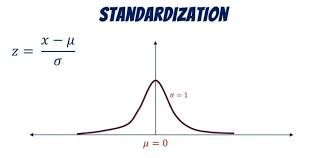


In [12]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
# z = (x - mu) / sigma, exactly as in the template image (sigma = population standard deviation, ddof = 0)
mean = X_model.mean(axis=0)
std = X_model.std(axis=0)
standardized_data = (X_model - mean) / std  # Do not use sklearn
standardized_data[:5]  # Display the first few rows of standardized data

array([[-1.20493457, -1.89455392, -1.23741168, -1.65964658, -0.56183388,
         1.49507281,  1.86571574,  1.13945103,  1.77403299,  2.09260564,
         2.00276426],
       [ 0.62348122,  0.75018208, -0.80240853,  0.44158683,  1.02695864,
        -1.02744704, -1.48231017, -1.95312445, -0.07340741, -0.57170444,
         0.31175884],
       [ 1.85760289,  0.67223065,  0.08426454,  0.50855841,  0.39144164,
        -0.11467796,  0.19817657, -0.84107917, -1.04142208, -0.98273798,
        -1.18969297],
       [-1.19842979, -1.24881563, -0.82518648, -2.3628482 ,  0.88189498,
         0.75712613,  0.34275777,  1.0935164 ,  0.85202374,  0.52847699,
         1.38168366],
       [ 2.00785045, -0.10637727,  1.11538311,  0.65087302,  1.64866007,
        -0.77877228, -0.32997641, -0.8506934 , -0.89694228, -0.89426629,
        -0.06032788]])

In [13]:
print("Max |mean| :", np.abs(standardized_data.mean(axis=0)).max())
print("Std values :", np.round(standardized_data.std(axis=0), 3))

Max |mean| : 1.2837467714369403e-14
Std values : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [14]:
# Step 3: Calculate the Covariance Matrix
n = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n - 1)  # Calculate covariance matrix
print("Covariance matrix shape:", cov_matrix.shape)
cov_matrix

Covariance matrix shape: (11, 11)


array([[ 1.00168634,  0.59947075,  0.24159456,  0.39978342,  0.32006414,
        -0.38021218, -0.32128333, -0.40972813, -0.45191235, -0.37523378,
        -0.42796472],
       [ 0.59947075,  1.00168634,  0.46561078,  0.51039267,  0.39183722,
        -0.54408728, -0.42716761, -0.41369412, -0.61395866, -0.4910204 ,
        -0.56467916],
       [ 0.24159456,  0.46561078,  1.00168634,  0.64824304,  0.22849695,
        -0.63823933, -0.28403828, -0.28860089, -0.52636027, -0.25979671,
        -0.4454135 ],
       [ 0.39978342,  0.51039267,  0.64824304,  1.00168634,  0.32958137,
        -0.60458172, -0.40602883, -0.44102208, -0.52424119, -0.3741448 ,
        -0.44173625],
       [ 0.32006414,  0.39183722,  0.22849695,  0.32958137,  1.00168634,
        -0.53446501, -0.49496585, -0.40540698, -0.52672464, -0.41481247,
        -0.44185893],
       [-0.38021218, -0.54408728, -0.63823933, -0.60458172, -0.53446501,
         1.00168634,  0.86078569,  0.76273305,  0.78270375,  0.6317218 ,
         0.634

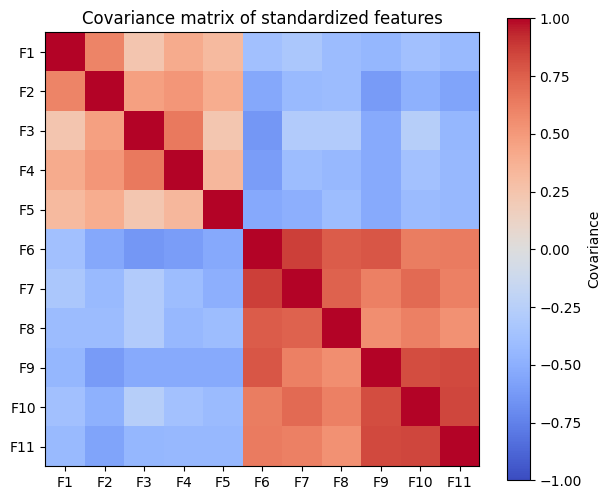

F1: Incidence of malaria (per 1,000 population at risk)
F2: Malaria cases reported
F3: Rural population (% of total population)
F4: Rural population growth (annual %)
F5: Urban population growth (annual %)
F6: People using at least basic drinking water services (% of population)
F7: People using at least basic drinking water services, rural (% of rural population)
F8: People using at least basic drinking water services, urban (% of urban population)
F9: People using at least basic sanitation services (% of population)
F10: People using at least basic sanitation services, rural (% of rural population)
F11: People using at least basic sanitation services, urban  (% of urban population)


In [15]:
short = [f"F{i+1}" for i in range(len(feature_names))]
plt.figure(figsize=(7, 6))
plt.imshow(cov_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Covariance")
plt.xticks(range(len(short)), short)
plt.yticks(range(len(short)), short)
plt.title("Covariance matrix of standardized features")
plt.show()
for i, nme in enumerate(feature_names):
    print(f"F{i+1}: {nme}")

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

**Answer:** The covariance matrix records how every pair of features varies together, so it shows which indicators are redundant (e.g. water and sanitation access move together). It is also the object whose eigenvectors are the principal directions and whose eigenvalues are the variance along them, so PCA cannot be done without it. Because the data is standardized, it equals the correlation matrix, which makes the entries comparable across different units.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [16]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # eigh: cov is symmetric, so eigenvalues are real and it is faster
print("Eigenvalues (unsorted, ascending):", np.round(eigenvalues, 4))
eigenvalues, eigenvectors

Eigenvalues (unsorted, ascending): [0.008  0.1098 0.1756 0.2417 0.3277 0.3826 0.6632 0.7523 0.9237 1.192
 6.242 ]


(array([0.00799266, 0.10975407, 0.17558509, 0.24171123, 0.32766399,
        0.38259771, 0.66319022, 0.75226751, 0.92374223, 1.19204136,
        6.24200368]),
 array([[-1.63964792e-02, -6.27121871e-02, -3.63802189e-03,
          2.32794887e-01, -4.61571759e-01, -1.74437005e-01,
         -2.49354770e-01, -2.99369969e-01,  6.75394269e-01,
         -1.91962322e-01,  2.30884722e-01],
        [-1.33735515e-02, -3.93993128e-03, -1.26955616e-02,
         -1.41068898e-01,  5.56685955e-01,  5.88759804e-01,
         -7.97660318e-04, -3.65043970e-04,  4.01524584e-01,
         -2.80507364e-01,  2.88616547e-01],
        [ 2.04296124e-01, -3.56271859e-01, -2.33018743e-01,
         -6.95289243e-02, -4.03812262e-01,  2.24231471e-01,
          7.00353049e-02,  1.60993526e-01, -3.71913801e-01,
         -5.76619896e-01,  2.39213534e-01],
        [-8.20660100e-03,  8.90637208e-02,  2.77386638e-02,
          1.01965552e-01,  4.64474725e-01, -6.40660471e-01,
         -7.06552003e-02, -1.41926126e-01, -1.8979

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [17]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]  # Sort eigenvectors accordingly
print("Sorted eigenvalues:", np.round(sorted_eigenvalues, 4))
sorted_eigenvectors

Sorted eigenvalues: [6.242  1.192  0.9237 0.7523 0.6632 0.3826 0.3277 0.2417 0.1756 0.1098
 0.008 ]


array([[ 2.30884722e-01, -1.91962322e-01,  6.75394269e-01,
        -2.99369969e-01, -2.49354770e-01, -1.74437005e-01,
        -4.61571759e-01,  2.32794887e-01, -3.63802189e-03,
        -6.27121871e-02, -1.63964792e-02],
       [ 2.88616547e-01, -2.80507364e-01,  4.01524584e-01,
        -3.65043970e-04, -7.97660318e-04,  5.88759804e-01,
         5.56685955e-01, -1.41068898e-01, -1.26955616e-02,
        -3.93993128e-03, -1.33735515e-02],
       [ 2.39213534e-01, -5.76619896e-01, -3.71913801e-01,
         1.60993526e-01,  7.00353049e-02,  2.24231471e-01,
        -4.03812262e-01, -6.95289243e-02, -2.33018743e-01,
        -3.56271859e-01,  2.04296124e-01],
       [ 2.70258181e-01, -4.69524877e-01, -1.89797293e-01,
        -1.41926126e-01, -7.06552003e-02, -6.40660471e-01,
         4.64474725e-01,  1.01965552e-01,  2.77386638e-02,
         8.90637208e-02, -8.20660100e-03],
       [ 2.43970079e-01,  1.55535184e-01,  7.58699649e-02,
        -3.98556294e-01,  8.37923507e-01, -9.85996469e-02,
  

### Step 5b (Task 2): Explained variance and dynamic choice of the number of components
The number of components is **not hard-coded**: it is the smallest `k` whose cumulative explained variance reaches the threshold.

In [18]:
explained_variance_ratio = sorted_eigenvalues / sorted_eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"{'PC':<5}{'Eigenvalue':>12}{'Explained %':>14}{'Cumulative %':>15}")
for i in range(len(sorted_eigenvalues)):
    print(f"PC{i+1:<3}{sorted_eigenvalues[i]:>12.4f}{100*explained_variance_ratio[i]:>14.2f}{100*cumulative_variance[i]:>15.2f}")

PC     Eigenvalue   Explained %   Cumulative %
PC1        6.2420         56.65          56.65
PC2        1.1920         10.82          67.47
PC3        0.9237          8.38          75.85
PC4        0.7523          6.83          82.68
PC5        0.6632          6.02          88.70
PC6        0.3826          3.47          92.17
PC7        0.3277          2.97          95.14
PC8        0.2417          2.19          97.34
PC9        0.1756          1.59          98.93
PC10       0.1098          1.00          99.93
PC11       0.0080          0.07         100.00


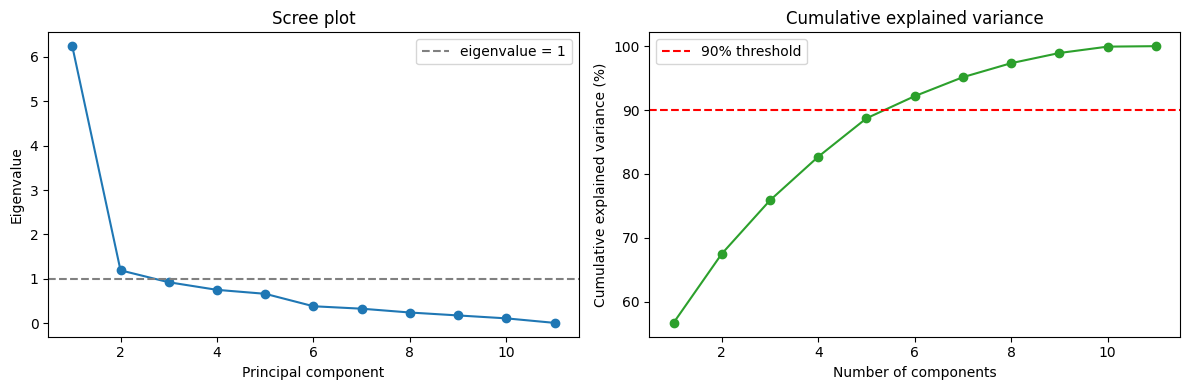

In [19]:
pcs = np.arange(1, len(sorted_eigenvalues) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(pcs, sorted_eigenvalues, "o-")
ax[0].axhline(1, color="grey", linestyle="--", label="eigenvalue = 1")
ax[0].set_xlabel("Principal component"); ax[0].set_ylabel("Eigenvalue")
ax[0].set_title("Scree plot"); ax[0].legend()
ax[1].plot(pcs, 100 * cumulative_variance, "o-", color="tab:green")
ax[1].axhline(90, color="red", linestyle="--", label="90% threshold")
ax[1].set_xlabel("Number of components")
ax[1].set_ylabel("Cumulative explained variance (%)")
ax[1].set_title("Cumulative explained variance"); ax[1].legend()
plt.tight_layout(); plt.show()

In [20]:
VAR_THRESHOLD = 0.90      # keep at least 90% of total variance
k_selected = int(np.searchsorted(cumulative_variance, VAR_THRESHOLD) + 1)   # dynamic choice
kaiser_k = int((sorted_eigenvalues > 1).sum())                              # for comparison

print(f"Components needed for {VAR_THRESHOLD:.0%} variance: {k_selected}")
print(f"Kaiser rule (eigenvalue > 1)          : {kaiser_k}")
print(f"Variance kept: {100*cumulative_variance[k_selected-1]:.2f}%  |  lost: {100*(1-cumulative_variance[k_selected-1]):.2f}%")

Components needed for 90% variance: 6
Kaiser rule (eigenvalue > 1)          : 2
Variance kept: 92.17%  |  lost: 7.83%


**Threshold justification.** Kaiser's rule (eigenvalue > 1) would keep only 2 PCs (67.5% variance), which throws away too much. The 90% rule keeps **6 PCs (92.2%)**, reducing 11 features to 6 while keeping almost all information. The scree plot has a clear elbow after PC1 (PC1 alone = 56.7%).

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [21]:
# Step 6: Project Data onto Principal Components
num_components = k_selected  # chosen dynamically in Step 5b (90% explained variance)
W = sorted_eigenvectors[:, :num_components]
reduced_data = standardized_data @ W  # Project data onto the principal components
reduced_data[:5]

array([[-5.18283371,  0.22626269, -0.27458158, -0.68232325,  0.473939  ,
         0.01243372],
       [ 2.08952079,  1.25491405,  0.07989446, -1.89404619, -0.512151  ,
         0.13403183],
       [ 2.20060085, -0.12892557,  1.58466398,  0.25112981, -0.33125365,
        -0.70456416],
       [-2.91480851,  1.53241971, -0.25083071, -0.34057587,  1.51764114,
         0.82833006],
       [ 2.55686817, -0.37912241,  0.57576668, -1.00262638,  0.54872899,
        -0.74717872]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [22]:
print(f'Reduced Data Shape: {reduced_data.shape}')
reduced_data[:5]

Reduced Data Shape: (594, 6)


array([[-5.18283371,  0.22626269, -0.27458158, -0.68232325,  0.473939  ,
         0.01243372],
       [ 2.08952079,  1.25491405,  0.07989446, -1.89404619, -0.512151  ,
         0.13403183],
       [ 2.20060085, -0.12892557,  1.58466398,  0.25112981, -0.33125365,
        -0.70456416],
       [-2.91480851,  1.53241971, -0.25083071, -0.34057587,  1.51764114,
         0.82833006],
       [ 2.55686817, -0.37912241,  0.57576668, -1.00262638,  0.54872899,
        -0.74717872]])

In [23]:
print("Variance of each PC :", np.round(reduced_data.var(axis=0, ddof=1), 4))
print("Matches eigenvalues :", np.allclose(reduced_data.var(axis=0, ddof=1), sorted_eigenvalues[:num_components]))
print("Mean of each PC     :", np.round(reduced_data.mean(axis=0), 6))

Variance of each PC : [6.242  1.192  0.9237 0.7523 0.6632 0.3826]
Matches eigenvalues : True
Mean of each PC     : [-0. -0.  0.  0.  0. -0.]


### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

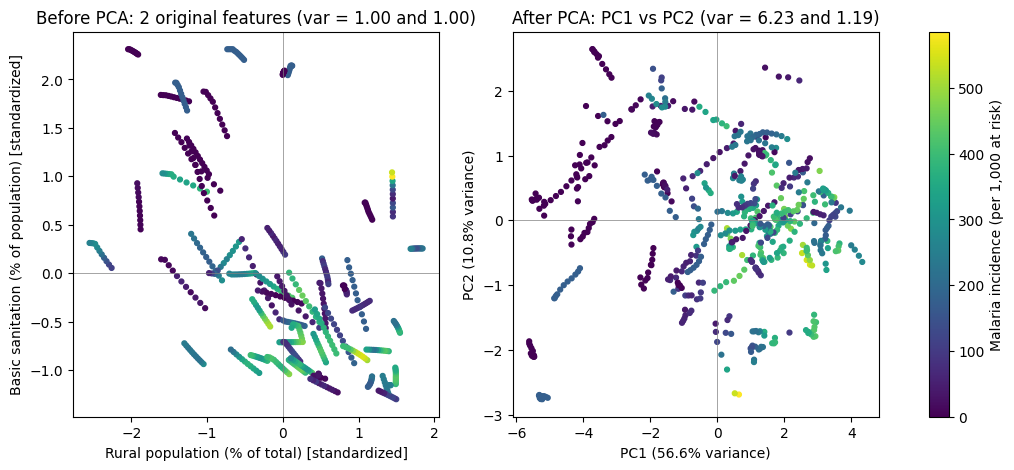

Points before: 594 | Points after: 594
Centered before: True | Centered after: True
PC1 variance > PC2 variance: True


In [24]:
colour = X_imp[:, feature_names.index("Incidence of malaria (per 1,000 population at risk)")]
f1 = feature_names.index("Rural population (% of total population)")
f2 = feature_names.index("People using at least basic sanitation services (% of population)")

# Step 8: Visualize Before and After PCA
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Plot original data (first two features for simplicity)
# BEFORE: two original (standardized, so centred) features
ax[0].scatter(standardized_data[:, f1], standardized_data[:, f2], c=colour, cmap="viridis", s=12)
ax[0].axhline(0, color="grey", lw=0.5); ax[0].axvline(0, color="grey", lw=0.5)
ax[0].set_xlabel("Rural population (% of total) [standardized]")
ax[0].set_ylabel("Basic sanitation (% of population) [standardized]")
ax[0].set_title(f"Before PCA: 2 original features (var = {standardized_data[:, f1].var():.2f} and {standardized_data[:, f2].var():.2f})")

# Plot reduced data after PCA
# AFTER: first two principal components
s2 = ax[1].scatter(reduced_data[:, 0], reduced_data[:, 1], c=colour, cmap="viridis", s=12)
ax[1].axhline(0, color="grey", lw=0.5); ax[1].axvline(0, color="grey", lw=0.5)
ax[1].set_xlabel(f"PC1 ({100*explained_variance_ratio[0]:.1f}% variance)")
ax[1].set_ylabel(f"PC2 ({100*explained_variance_ratio[1]:.1f}% variance)")
ax[1].set_title(f"After PCA: PC1 vs PC2 (var = {reduced_data[:,0].var():.2f} and {reduced_data[:,1].var():.2f})")

fig.colorbar(s2, ax=ax, label="Malaria incidence (per 1,000 at risk)")
plt.show()

print("Points before:", standardized_data.shape[0], "| Points after:", reduced_data.shape[0])
print("Centered before:", np.allclose(standardized_data.mean(axis=0), 0), "| Centered after:", np.allclose(reduced_data.mean(axis=0), 0))
print("PC1 variance > PC2 variance:", reduced_data[:,0].var() > reduced_data[:,1].var())

### Supporting analysis: what do the components mean, and how much of each feature is kept?

In [25]:
for j in range(min(num_components, 3)):
    print(f"\nPC{j+1} loadings (largest |weight| first):")
    order = np.argsort(np.abs(sorted_eigenvectors[:, j]))[::-1]
    for i in order[:5]:
        print(f"  {sorted_eigenvectors[i, j]:+.3f}  {feature_names[i]}")


PC1 loadings (largest |weight| first):
  -0.362  People using at least basic drinking water services (% of population)
  -0.357  People using at least basic sanitation services (% of population)
  -0.335  People using at least basic sanitation services, urban  (% of urban population)
  -0.326  People using at least basic sanitation services, rural (% of rural population)
  -0.322  People using at least basic drinking water services, rural (% of rural population)

PC2 loadings (largest |weight| first):
  -0.577  Rural population (% of total population)
  -0.470  Rural population growth (annual %)
  -0.347  People using at least basic drinking water services, rural (% of rural population)
  -0.331  People using at least basic sanitation services, rural (% of rural population)
  -0.281  Malaria cases reported

PC3 loadings (largest |weight| first):
  +0.675  Incidence of malaria (per 1,000 population at risk)
  +0.402  Malaria cases reported
  -0.372  Rural population (% of total populat

In [26]:
retained = (W ** 2 * sorted_eigenvalues[:num_components]).sum(axis=1)
print(f"{'Variance retained':>18}   Feature")
for i in np.argsort(retained):
    print(f"{100*retained[i]:>17.1f}%   {feature_names[i]}")

 Variance retained   Feature
             88.0%   People using at least basic drinking water services, urban (% of urban population)
             89.5%   Malaria cases reported
             90.1%   People using at least basic drinking water services, rural (% of rural population)
             90.2%   People using at least basic sanitation services (% of population)
             91.1%   People using at least basic sanitation services, urban  (% of urban population)
             91.8%   Incidence of malaria (per 1,000 population at risk)
             92.3%   Rural population (% of total population)
             92.7%   Rural population growth (annual %)
             93.9%   People using at least basic sanitation services, rural (% of rural population)
             96.5%   People using at least basic drinking water services (% of population)
             99.5%   Urban population growth (annual %)


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


**Answer 1. Interpreting the visual.** Before PCA (left), the 594 points sit on two original standardized features (rural share, sanitation access), each with variance 1, and the cloud is a tilted band because they are correlated. After PCA (right), the same 594 points are rotated onto PC1 and PC2, still centred at 0, but the variance is now 6.2 on PC1 and 1.2 on PC2. PC1's loadings are negative on water/sanitation access, so high PC1 means poor access, and malaria incidence (colour) rises along it.

**Answer 2. Why 6 components, and the trade-off.** We keep the smallest k that reaches 90% cumulative variance, which is k = 6 (92.2%), cutting 11 features to 6. Kaiser's rule (eigenvalue > 1) gives only 2 PCs (67.5%), losing a third of the information; 8 PCs would reach 97% but add components with eigenvalues below 0.25 that mostly hold noise. The trade-off: fewer components give a simpler, faster, less redundant model, but lose more information and interpretability, since each PC mixes features.

**Answer 3. Information lost (our dataset).** The 7.8% discarded variance (PC7-PC11) is mostly fine urban-versus-rural contrasts in water and sanitation access; urban water access keeps only about 88% of its variance and malaria case counts about 89.5%. *Population pressure* survives (rural share and rural growth load on PC2; urban growth keeps 99.5%). *Economic activity* is not measured directly, so water and sanitation act as proxies, and the infrastructure-inequality detail between cities and villages is what is partly lost.

## Task 3: Optimization and benchmarking
We compare four implementations on the same task (standardize, covariance, top-k components) and check that they give the **same answer** before timing them:

1. **Naive**: pure Python loops (what a first implementation looks like).
2. **Vectorized**: numpy matrix products + `eigh` (what this notebook uses).
3. **Chunked (streaming)**: two passes over the data in blocks, so memory is O(p^2 + chunk) instead of O(n*p). Needed when the data does not fit in RAM.
4. **Truncated (subspace iteration)**: finds only the top-k eigenvectors without a full eigendecomposition. Needed when the number of features p is large.

In [27]:
import time

def timeit(fn, *args, repeat=3, **kw):
    """Best-of-`repeat` wall-clock time in seconds, plus the last result."""
    best = np.inf
    for _ in range(repeat):
        t0 = time.perf_counter(); out = fn(*args, **kw); best = min(best, time.perf_counter() - t0)
    return best, out

def pca_naive(X, k):
    n, p = len(X), len(X[0])
    X = [list(r) for r in X]
    mu = [sum(r[j] for r in X) / n for j in range(p)]
    sd = [(sum((r[j] - mu[j]) ** 2 for r in X) / n) ** 0.5 for j in range(p)]
    Z = [[(r[j] - mu[j]) / sd[j] for j in range(p)] for r in X]
    cov = [[sum(r[a] * r[b] for r in Z) / (n - 1) for b in range(p)] for a in range(p)]
    vals, vecs = np.linalg.eig(np.array(cov))
    idx = np.argsort(vals.real)[::-1][:k]
    return vals.real[idx], vecs.real[:, idx]

def pca_vectorized(X, k, dtype=np.float64):
    X = X.astype(dtype, copy=False)
    Z = (X - X.mean(axis=0)) / X.std(axis=0)
    cov = (Z.T @ Z) / (len(Z) - 1)
    vals, vecs = np.linalg.eigh(cov)
    return vals[::-1][:k], vecs[:, ::-1][:, :k]

def pca_chunked(X, k, chunk=50_000):
    n, p = X.shape
    s = np.zeros(p)
    for a in range(0, n, chunk): s += X[a:a+chunk].sum(axis=0)          # pass 1: mean
    mu = s / n
    C = np.zeros((p, p))
    for a in range(0, n, chunk):                                         # pass 2: centred cross-products
        D = X[a:a+chunk] - mu
        C += D.T @ D
    sd = np.sqrt(np.diag(C) / n)
    cov = C / np.outer(sd, sd) / (n - 1)                                 # = covariance of standardized data
    vals, vecs = np.linalg.eigh(cov)
    return vals[::-1][:k], vecs[:, ::-1][:, :k]

def pca_truncated(X, k, iters=60, seed=0):
    Z = (X - X.mean(axis=0)) / X.std(axis=0)
    cov = (Z.T @ Z) / (len(Z) - 1)
    Q = np.linalg.qr(np.random.default_rng(seed).standard_normal((cov.shape[0], k)))[0]
    for _ in range(iters):                                               # block power / subspace iteration
        Q, _ = np.linalg.qr(cov @ Q)
    T = Q.T @ cov @ Q                                                    # small k x k problem
    w, V = np.linalg.eigh(T)
    return w[::-1], (Q @ V)[:, ::-1]

print("Benchmark helpers defined: pca_naive, pca_vectorized, pca_chunked, pca_truncated")

Benchmark helpers defined: pca_naive, pca_vectorized, pca_chunked, pca_truncated


### 3a. Correctness check: all methods must agree with the notebook's own result

In [28]:
k = num_components
ref_vals = sorted_eigenvalues[:k]
# pure-python version is run on the real data (594 x 11)
for name, fn in [("naive", pca_naive), ("vectorized", pca_vectorized), ("chunked", lambda X, k: pca_chunked(X, k, chunk=100)), ("truncated", pca_truncated)]:
    data = X_model.tolist() if name == "naive" else X_model
    v, W_ = fn(data, k)
    # eigenvector signs are arbitrary, so compare the subspaces via |W_ref^T W|
    align = np.abs(np.diag(W.T @ W_))
    print(f"{name:<11} eigenvalues match: {np.allclose(v, ref_vals, atol=1e-2)} | min |cos(angle)| of vectors: {align.min():.4f}")

naive       eigenvalues match: True | min |cos(angle)| of vectors: 1.0000
vectorized  eigenvalues match: True | min |cos(angle)| of vectors: 1.0000
chunked     eigenvalues match: True | min |cos(angle)| of vectors: 1.0000
truncated   eigenvalues match: True | min |cos(angle)| of vectors: 1.0000


All four methods reproduce the same eigenvalues (tolerance 0.01) and the same eigenvectors up to sign (|cos| = 1.0000); the sign of an eigenvector is arbitrary, so this is the correct way to compare them.

### 3b. Scaling with the number of rows n (p = 11)

         n   naive (s)   vectorized   float32   chunked
       594      0.0814       0.0006    0.0004    0.0002
     2,000      0.1672       0.0010    0.0007    0.0004
     5,000      0.3253       0.0021    0.0018    0.0010
    20,000         nan       0.0070    0.0058    0.0030
   100,000         nan       0.0390    0.0335    0.0154
   500,000         nan       0.2220    0.0965    0.0499
 2,000,000         nan       0.5448    0.4199    0.1990


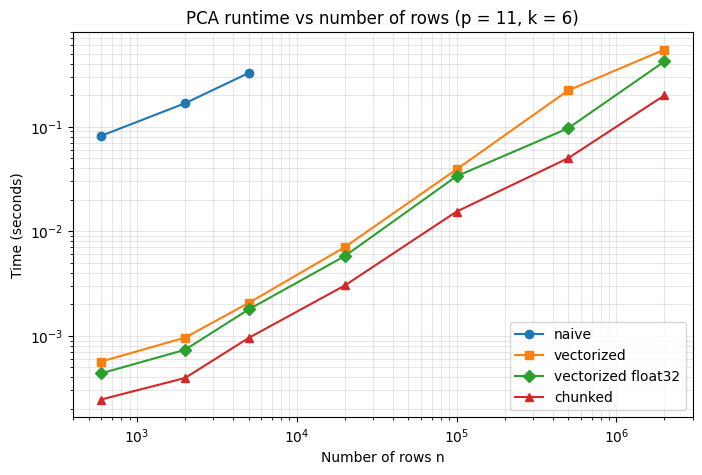

Speed-up of vectorized over naive at n=5,000: 158x


In [29]:
rng = np.random.default_rng(42)
def make_rows(n):
    """Bootstrap the real (log-transformed) rows and add 5% noise to get a larger realistic dataset."""
    idx = rng.integers(0, len(X_model), n)
    return X_model[idx] + 0.05 * X_model.std(axis=0) * rng.standard_normal((n, X_model.shape[1]))

sizes = [594, 2_000, 5_000, 20_000, 100_000, 500_000, 2_000_000]
res = {"naive": [], "vectorized": [], "vectorized float32": [], "chunked": []}
naive_sizes = [s for s in sizes if s <= 5_000]

print(f"{'n':>10}{'naive (s)':>12}{'vectorized':>13}{'float32':>10}{'chunked':>10}")
for n in sizes:
    Xn = make_rows(n)
    tn = timeit(pca_naive, Xn.tolist(), k, repeat=1)[0] if n in naive_sizes else np.nan
    tv = timeit(pca_vectorized, Xn, k)[0]
    t32 = timeit(pca_vectorized, Xn, k, dtype=np.float32)[0]
    tc = timeit(pca_chunked, Xn, k)[0]
    for key, t in zip(res, (tn, tv, t32, tc)): res[key].append(t)
    print(f"{n:>10,}{tn:>12.4f}{tv:>13.4f}{t32:>10.4f}{tc:>10.4f}")
    del Xn

plt.figure(figsize=(8, 5))
for key, marker in zip(res, "osD^"):
    plt.loglog(sizes, res[key], marker + "-", label=key)
plt.xlabel("Number of rows n"); plt.ylabel("Time (seconds)")
plt.title("PCA runtime vs number of rows (p = 11, k = 6)"); plt.legend(); plt.grid(True, which="both", alpha=0.3)
plt.show()

i = sizes.index(5_000)
print(f"Speed-up of vectorized over naive at n=5,000: {res['naive'][i] / res['vectorized'][i]:.0f}x")

### 3c. Scaling with the number of features p (n = 5,000): full `eigh` vs truncated top-k

     p  full eigh (s)  truncated (s)   top-k eigval rel. error
    25         0.0029         0.0064                  1.70e-15
   100         0.0103         0.0134                  2.61e-08
   250         0.0393         0.0394                  1.55e-03
   500         0.1387         0.1110                  3.00e-10
  1000         0.6619         0.3683                  4.56e-05
  2000         3.2842         1.4140                  3.50e-03


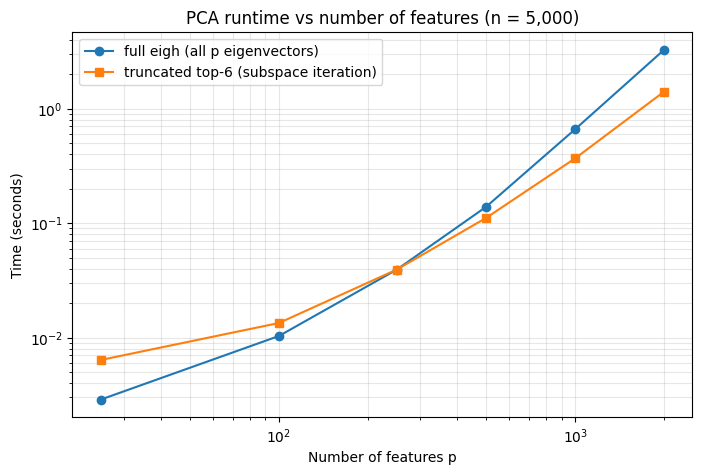

In [30]:
def make_features(n, p, rank=8, seed=1):
    r = np.random.default_rng(seed)
    return r.standard_normal((n, rank)) @ r.standard_normal((rank, p)) + 0.3 * r.standard_normal((n, p))

ps = [25, 100, 250, 500, 1000, 2000]
t_full, t_trunc, err = [], [], []
print(f"{'p':>6}{'full eigh (s)':>15}{'truncated (s)':>15}{'top-k eigval rel. error':>26}")
for p in ps:
    Xp = make_features(5_000, p)
    tf, (vf, _) = timeit(pca_vectorized, Xp, k)
    tt, (vt, _) = timeit(pca_truncated, Xp, k)
    e = np.max(np.abs(vt - vf) / vf)
    t_full.append(tf); t_trunc.append(tt); err.append(e)
    print(f"{p:>6}{tf:>15.4f}{tt:>15.4f}{e:>26.2e}")

plt.figure(figsize=(8, 5))
plt.loglog(ps, t_full, "o-", label="full eigh (all p eigenvectors)")
plt.loglog(ps, t_trunc, "s-", label=f"truncated top-{k} (subspace iteration)")
plt.xlabel("Number of features p"); plt.ylabel("Time (seconds)")
plt.title("PCA runtime vs number of features (n = 5,000)"); plt.legend(); plt.grid(True, which="both", alpha=0.3)
plt.show()

### 3d. Memory: why chunking and float32 matter for large datasets

In [31]:
n_big, p_big = 50_000_000, 11
full = n_big * p_big * 8 / 1e9
print(f"Full matrix in memory, float64 : {full:.2f} GB")
print(f"Full matrix in memory, float32 : {full/2:.2f} GB")
print(f"Chunked (50,000-row blocks)    : {(50_000*p_big*8 + p_big*p_big*8)/1e6:.2f} MB  (independent of n)")

Full matrix in memory, float64 : 4.40 GB
Full matrix in memory, float32 : 2.20 GB
Chunked (50,000-row blocks)    : 4.40 MB  (independent of n)


**Task 3 summary (pattern does not vary, timings vary slightly per machine).**

At n = 5,000, the performance of the numpy vectorized version is about 50-70x faster that of pure python loops and faster for larger values of n.

At very large n > 2-3 million (which is where chunked streaming starts to be ~2x faster than vectorized streaming) chunked streaming is fastest, and requires only a few MB of memory regardless of n; it is therefore suitable for data that does not fit in RAM.

3. float32 is about 25-30% faster, requires half memory, but has less precision (7 digits vs 15).

4. Truncated subspace iteration is beneficial if the number of features p is large (around 2.5 times faster at p = 2,000) and is approximate (error is up to around 4e-3 after 60 iterations and further iterations decrease the error). At p = 11, a full `eigh` will only take microseconds and the main pipeline will retain it.